In [1]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
import keras
from keras import optimizers
#from keras.preprocessing.image import ImageDataGenerator, load_img, image
#from keras.preprocessing.image import load_img, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

In [2]:
import os
import pandas as pd

img_path = '128_unlabeled/'

# list only image files (adjust extensions if needed)
filenames = [f for f in os.listdir(img_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# label from filename prefix
categories = ['1' if f.endswith('yellow1.png') else '0' for f in filenames]

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)
df.head()

(1764, 2)


,filename,category
0,m05_tile128_x02944_y01536_yellow0.png,0
1,m05_tile128_x01408_y03200_yellow0.png,0
2,m05_tile128_x00256_y04224_yellow0.png,0
3,m05_tile128_x00128_y00640_yellow0.png,0
4,m05_tile128_x00896_y03072_yellow0.png,0


In [3]:
df['category'].value_counts()

category
0    1687
1      77
Name: count, dtype: int64

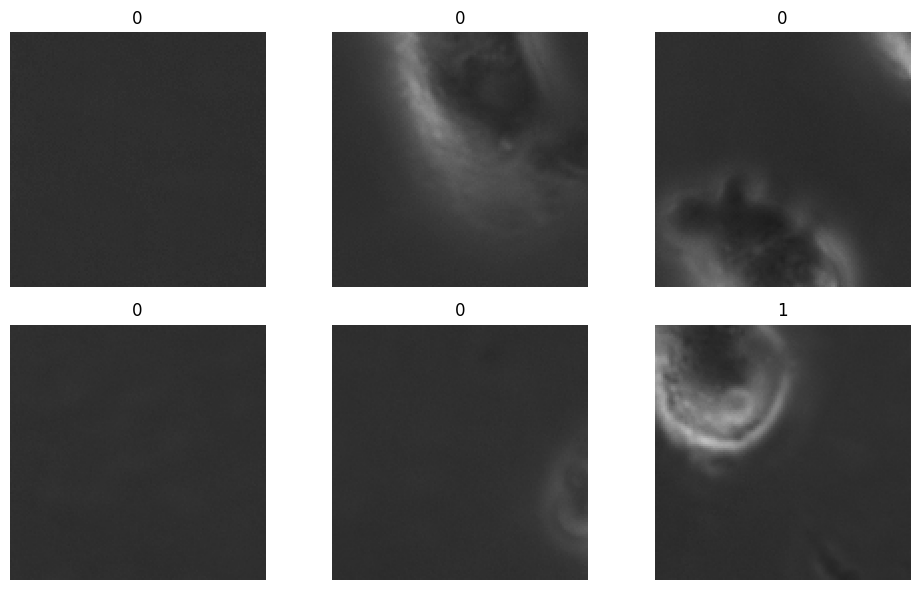

In [4]:
import os, random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

IMG_DIR = '128_unlabeled/'   # keep as directory
IMAGE_SIZE = (256, 256)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    full_path = os.path.join(IMG_DIR, filename)  # don't overwrite IMG_DIR
    image = load_img(full_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Model

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

INPUT_SHAPE = (256, 256, 3)

class_mode="binary"

# VGG16 base
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers
for layer in vgg_base.layers:
    layer.trainable = False

# Unfreeze last two layers with weights
unfroze = 0
for layer in reversed(vgg_base.layers):
    if layer.weights:
        layer.trainable = True
        unfroze += 1
        if unfroze == 2:
            break

# Verify trainability
for i, layer in enumerate(vgg_base.layers):
    print(f"{i:02d} {layer.name:25s} trainable={layer.trainable}")

# Explicit input layer
# 'This makes the model immediately callable and avoids a lot of “undefined output” issues.'
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization

INPUT_SHAPE = (256, 256, 3)


# Build Sequential model
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dense(1, activation="sigmoid")   # categorical output
])

# Callbacks
earlystop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="model.tnt_128_vgg16.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


#model.compile(
#    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#    loss="binary_crossentropy",
#    metrics=["accuracy"]
#)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

model.summary()

00 input_layer               trainable=False
01 block1_conv1              trainable=False
02 block1_conv2              trainable=False
03 block1_pool               trainable=False
04 block2_conv1              trainable=False
05 block2_conv2              trainable=False
06 block2_pool               trainable=False
07 block3_conv1              trainable=False
08 block3_conv2              trainable=False
09 block3_conv3              trainable=False
10 block3_pool               trainable=False
11 block4_conv1              trainable=False
12 block4_conv2              trainable=False
13 block4_conv3              trainable=False
14 block4_pool               trainable=False
15 block5_conv1              trainable=False
16 block5_conv2              trainable=True
17 block5_conv3              trainable=True
18 block5_pool               trainable=False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,909,761 (72.14 MB)

 Trainable params: 8,914,433 (34.01 MB)

 Non-trainable params: 9,995,328 (38.13 MB)

Data preparation

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1) Train/Validation split (20% validation)
train_df, valid_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]  # keeps class balance consistent
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

print("\nTrain class counts:")
print(train_df["category"].value_counts())

print("\nValid class counts:")
print(valid_df["category"].value_counts())

# 2) Batch size
BATCH_SIZE = 20

# 3) Image generators (use VGG16 preprocess_input)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 4) Flow from dataframe
TARGET_SIZE = (256, 256)

import math
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_DIR = "128_unlabeled/"   # <- the one you just validated
TARGET_SIZE = (256, 256)
BATCH_SIZE = 20

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMG_DIR,          # <- FIX
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=IMG_DIR,          # <- FIX
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("class_indices:", train_generator.class_indices)

steps_per_epoch = math.ceil(train_generator.n / train_generator.batch_size)
validation_steps = math.ceil(valid_generator.n / valid_generator.batch_size)

print("Found train:", train_generator.n, "valid:", valid_generator.n)
print("steps_per_epoch:", steps_per_epoch, "validation_steps:", validation_steps)


Train shape: (1411, 2)
Valid shape: (353, 2)

Train class counts:
category
0    1349
1      62
Name: count, dtype: int64

Valid class counts:
category
0    338
1     15
Name: count, dtype: int64
Found 1411 validated image filenames belonging to 2 classes.
Found 353 validated image filenames belonging to 2 classes.
class_indices: {'0': 0, '1': 1}
Found train: 1411 valid: 353
steps_per_epoch: 71 validation_steps: 18


# Train model - more detailed version, accuracy for each step within an epoch

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback

class BatchHistory(Callback):
    def on_train_begin(self, logs=None):
        self.batch_loss = []
        self.batch_acc = []
        self.epoch_ends = []  # global-step index where each epoch ends

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_loss.append(logs.get("loss"))
        # depending on your compile(), this might be "accuracy" or "binary_accuracy"
        self.batch_acc.append(logs.get("accuracy", logs.get("binary_accuracy")))

    def on_epoch_end(self, epoch, logs=None):
        # mark the end step for this epoch
        self.epoch_ends.append(len(self.batch_loss))

batch_hist = BatchHistory()

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[earlystop, checkpoint, batch_hist],
    verbose=1
)


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5614 - auc: 0.5952 - loss: 0.8303 - precision: 0.0634 - recall: 0.5825
Epoch 1: val_loss improved from inf to 0.27162, saving model to model.tnt_vgg16.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 488s 7s/step - accuracy: 0.5615 - auc: 0.5951 - loss: 0.8299 - precision: 0.0633 - recall: 0.5822 - val_accuracy: 0.8895 - val_auc: 0.6970 - val_loss: 0.2716 - val_precision: 0.1471 - val_recall: 0.3333
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7095 - auc: 0.9590 - loss: 0.6467 - precision: 0.1351 - recall: 0.9852
Epoch 2: val_loss did not improve from 0.27162
71/71 ━━━━━━━━━━━━━━━━━━━━ 503s 7s/step - accuracy: 0.7095 - auc: 0.9587 - loss: 0.6466 - precision: 0.1350 - recall: 0.9847 - val_accuracy: 0.9207 - val_auc: 0.7105 - val_loss: 0.3174 - val_precision: 0.2400 - val_recall: 0.4000
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7872 - auc: 0.9806 - loss: 0.5666 - precision: 0.1763 - recall: 0.9897
Epoch

# Detailed plot, shows squiggles within each epoch.

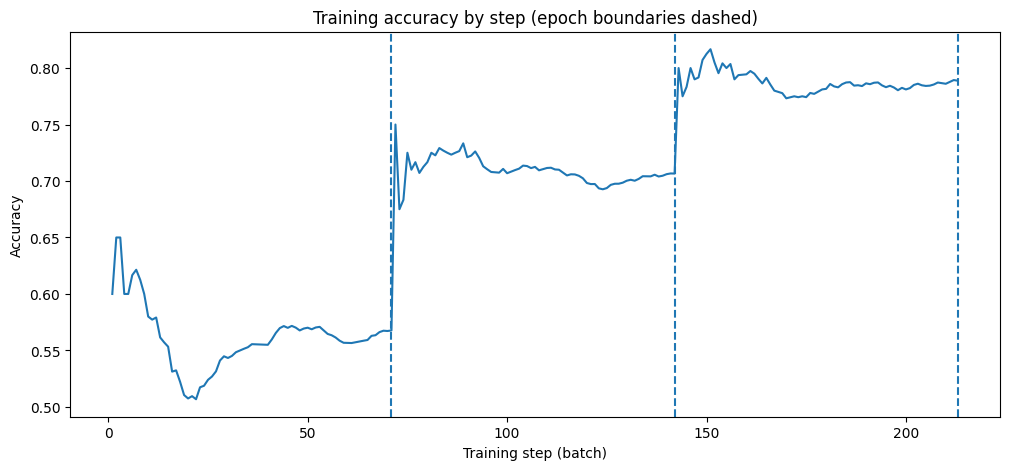

In [8]:
# ---- Plot continuous per-step accuracy with epoch markers ----
steps = np.arange(1, len(batch_hist.batch_acc) + 1)

plt.figure(figsize=(12,5))
plt.plot(steps, batch_hist.batch_acc)
for e_end in batch_hist.epoch_ends:
    plt.axvline(e_end, linestyle="--")  # epoch boundary markers
plt.xlabel("Training step (batch)")
plt.ylabel("Accuracy")
plt.title("Training accuracy by step (epoch boundaries dashed)")
plt.show()

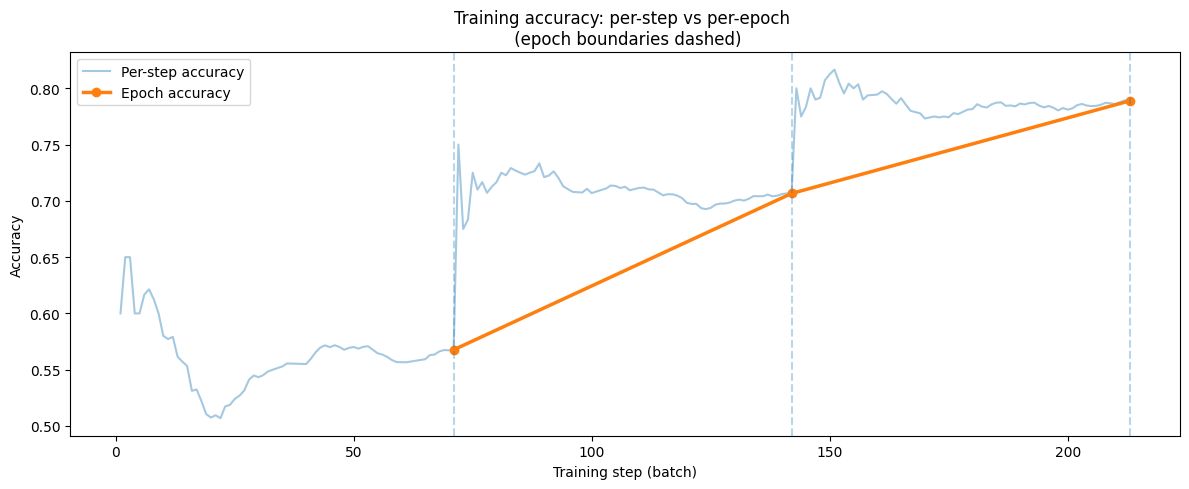

In [9]:
# Continuous steps
steps = np.arange(1, len(batch_hist.batch_acc) + 1)

# Epoch accuracy from Keras history
epoch_acc = history.history["accuracy"]

plt.figure(figsize=(12, 5))

# Per-step accuracy (noisy)
plt.plot(steps, batch_hist.batch_acc, alpha=0.4, label="Per-step accuracy")

# Epoch accuracy projected onto step axis
epoch_step_x = batch_hist.epoch_ends
plt.plot(
    epoch_step_x,
    epoch_acc,
    marker="o",
    linewidth=2.5,
    label="Epoch accuracy"
)

# Epoch boundaries
for e_end in batch_hist.epoch_ends:
    plt.axvline(e_end, linestyle="--", alpha=0.3)

plt.xlabel("Training step (batch)")
plt.ylabel("Accuracy")
plt.title("Training accuracy: per-step vs per-epoch \n (epoch boundaries dashed)")
plt.legend()
plt.tight_layout()
plt.show()


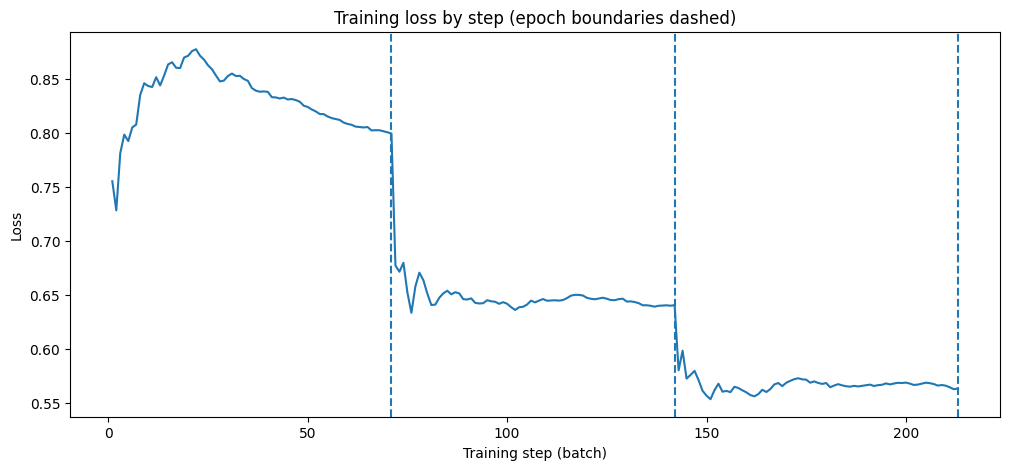

In [10]:
# ---- Optional: loss too ----
plt.figure(figsize=(12,5))
plt.plot(steps, batch_hist.batch_loss)
for e_end in batch_hist.epoch_ends:
    plt.axvline(e_end, linestyle="--")
plt.xlabel("Training step (batch)")
plt.ylabel("Loss")
plt.title("Training loss by step (epoch boundaries dashed)")
plt.show()

# Build dataframe comparing correctness and confidence

In [11]:
# Build dataframe comparing predictions with correctness and confidence
import math
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Make a stable copy in a known order
df_pred = df.copy().reset_index(drop=True)

BATCH_SIZE = 20
TARGET_SIZE = (256, 256)  # must match training

pred_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Important: shuffle=False so predictions line up with df_pred row-for-row
pred_gen = pred_datagen.flow_from_dataframe(
    dataframe=df_pred,
    directory=IMG_DIR,
    x_col="filename",
    y_col="category",     # keep y so we get class_indices and can compute correctness
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",  # OK even if model is softmax; we only use it for labels & class_indices
    shuffle=False
)

steps = math.ceil(pred_gen.n / pred_gen.batch_size)

# Predict
yhat = model.predict(pred_gen, steps=steps, verbose=1)

# Convert model outputs to P(man) robustly:
# - sigmoid model => shape (n,1)
# - softmax model => shape (n,2)
class_indices = pred_gen.class_indices          # e.g. {'female': 0, 'man': 1}
idx_man = class_indices.get("man", 1)           # fallback if keys differ

if yhat.ndim == 2 and yhat.shape[1] == 1:
    # sigmoid
    p_man = yhat[:, 0]
elif yhat.ndim == 2 and yhat.shape[1] == 2:
    # softmax
    p_man = yhat[:, idx_man]
else:
    raise ValueError(f"Unexpected prediction shape: {yhat.shape}")

# Predicted label + confidence
df_pred["p_tnt"] = p_man
df_pred["p_no_tnt"] = 1 - p_man
df_pred["pred_category"] = np.where(df_pred["p_tnt"] >= 0.5, "1", "0")
df_pred["pred_confidence"] = np.maximum(df_pred["p_tnt"], df_pred["p_no_tnt"])

# Compare to actual
df_pred["correct"] = (df_pred["pred_category"] == df_pred["category"]).astype(int)

# Quick summary
print(df_pred[["category", "pred_category", "correct"]].value_counts())
print("Accuracy:", df_pred["correct"].mean())

df_pred.head()


Found 1764 validated image filenames belonging to 2 classes.


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


89/89 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step
category  pred_category  correct
0         0              1          1573
          1              0           114
1         1              1            49
          0              0            28
Name: count, dtype: int64
Accuracy: 0.9195011337868481


,filename,category,p_tnt,p_no_tnt,pred_category,pred_confidence,correct
0,m05_tile128_x02944_y01536_yellow0.png,0,0.500184,0.499816,1,0.500184,0
1,m05_tile128_x01408_y03200_yellow0.png,0,0.140249,0.859751,0,0.859751,1
2,m05_tile128_x00256_y04224_yellow0.png,0,0.042542,0.957458,0,0.957458,1
3,m05_tile128_x00128_y00640_yellow0.png,0,0.046565,0.953435,0,0.953435,1
4,m05_tile128_x00896_y03072_yellow0.png,0,0.033406,0.966594,0,0.966594,1


# What was the most confident incorrect prediction? Let's see it next to the labeled dataset. If it's a false negative, there will be a yellow line on the right image.

Most confident incorrect prediction
Filename: m05_tile128_x02304_y00128_yellow0.png
Actual: 0 | Predicted: 1 | Confidence: 0.999


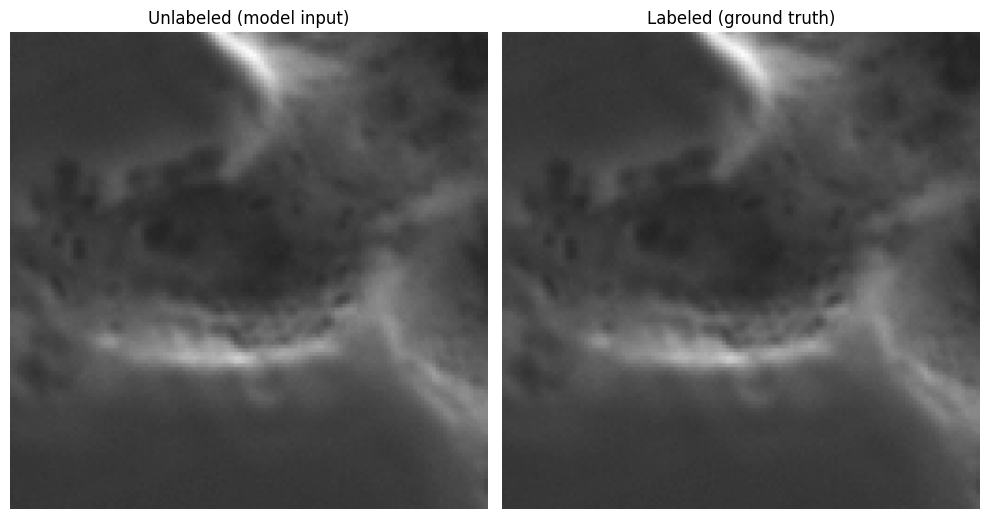

In [19]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import os

# --- directories / display settings ---
UNLABELED_DIR = "128_unlabeled"
LABELED_DIR   = "128_labeled"
DISPLAY_SIZE  = (256, 256)

# --- select MOST CONFIDENT INCORRECT prediction ---
incorrect_df = df_pred[df_pred["correct"] == 0]

if incorrect_df.empty:
    print("No incorrect predictions found.")
else:
    row = (
        incorrect_df
        .sort_values("pred_confidence", ascending=False)
        .iloc[0]
    )

    filename = row["filename"]

    # Load both images
    img_unlabeled = load_img(
        os.path.join(UNLABELED_DIR, filename),
        target_size=DISPLAY_SIZE
    )

    img_labeled = load_img(
        os.path.join(LABELED_DIR, filename),
        target_size=DISPLAY_SIZE
    )

    # Print metadata outside the images
    print("=" * 80)
    print("Most confident incorrect prediction")
    print("Filename:", filename)
    print(f"Actual: {row['category']} | Predicted: {row['pred_category']} | "
          f"Confidence: {row['pred_confidence']:.3f}")
    print("=" * 80)

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    axes[0].imshow(img_unlabeled)
    axes[0].set_title("Unlabeled (model input)")
    axes[0].axis("off")

    axes[1].imshow(img_labeled)
    axes[1].set_title("Labeled (ground truth)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Were there any false negatives? Let's see the most confident one if any.

In [20]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import os

# --- directories / display settings ---
UNLABELED_DIR = "128_unlabeled"
LABELED_DIR   = "128_labeled"
DISPLAY_SIZE  = (256, 256)

# --- pick the MOST CONFIDENT FALSE NEGATIVE (actual=1, predicted=0) ---
fn_df = df_pred[
    (df_pred["category"] == 1) &
    (df_pred["pred_category"] == 0)
]

if fn_df.empty:
    print("No false negatives found.")
else:
    row = fn_df.sort_values("pred_confidence", ascending=False).iloc[0]
    filename = row["filename"]

    # Load both images
    img_unlabeled = load_img(
        os.path.join(UNLABELED_DIR, filename),
        target_size=DISPLAY_SIZE
    )

    img_labeled = load_img(
        os.path.join(LABELED_DIR, filename),
        target_size=DISPLAY_SIZE
    )

    # Print metadata outside the images
    print("=" * 80)
    print("Most confident FALSE NEGATIVE")
    print("Filename:", filename)
    print(f"Actual: {row['category']} | Predicted: {row['pred_category']} | "
          f"Confidence (pred=0): {row['pred_confidence']:.3f}")
    print("=" * 80)

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    axes[0].imshow(img_unlabeled)
    axes[0].set_title("Unlabeled (model input)")
    axes[0].axis("off")

    axes[1].imshow(img_labeled)
    axes[1].set_title("Labeled (ground truth)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


No false negatives found.
